# Monty Hall Problem

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

## single simulation

In [85]:
doors = np.array([0, 1, 0], dtype="bool")
#0 or False is a goat
#1 or True is the car

In [87]:
N = 500
conservative = 0
switcher = 0
last = 0
for i in range(N):
    choice = random.randint(0, 2) #choosing a random index, which is a door
    if doors[choice]:
        conservative += 1
        #+1 win because their initial choice was right
        
    #remaining doors
    rem = np.delete(doors, choice)
    #opening the goat door...
    #... if there is still a car in the other door, the switcher is going to get it
    #so, if there is a True value in rem, the switcher is going to win
    if True in rem:
        switcher += 1
    
    #doors for the last player are always just one car and one goat
    if random.randint(0, 1):
        last += 1

([<matplotlib.axis.YTick at 0x24053fbef00>,
 [Text(0, 0.3333333333333333, '1/3'),
  Text(0, 0.5, '1/2'),
  Text(0, 0.6666666666666666, '2/3'),
  Text(0, 0.0, '0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6, '0.6'),
  Text(0, 0.8, '0.8')])

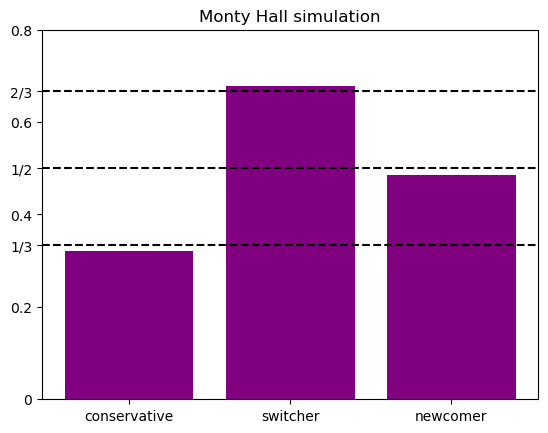

In [88]:
players = ["conservative", "switcher", "newcomer"]
plt.bar(players, [conservative/N, switcher/N, last/N], color="purple")
plt.title("Monty Hall simulation")
plt.axhline(1/3, color="k", ls="--")
plt.axhline(2/3, color="k", ls="--")
plt.axhline(1/2, color="k", ls="--")
plt.yticks([1/3, 1/2, 2/3, 0, 0.2, 0.4, 0.6, 0.8], ["1/3", "1/2", "2/3", "0", "0.2", "0.4", "0.6", "0.8"])

## convergence

In [89]:
N_sim = np.logspace(1, 4, 10)
conservative = np.zeros(len(N_sim))
switcher = np.zeros(len(N_sim))
last = np.zeros(len(N_sim))

for n in N_sim:
    c = s = l = 0
    for i in range(int(n)):
        choice = random.randint(0, 2)
        #conservative:
        if doors[choice]:
            c += 1
            
        #remaining doors
        rem = np.delete(doors, choice)
        #switcher:
        if True in rem:
            s += 1
        
        #last player:
        if random.randint(0, 1):
            l += 1
    conservative[N_sim==n] = c/n
    switcher[N_sim==n] = s/n
    last[N_sim==n] = l/n

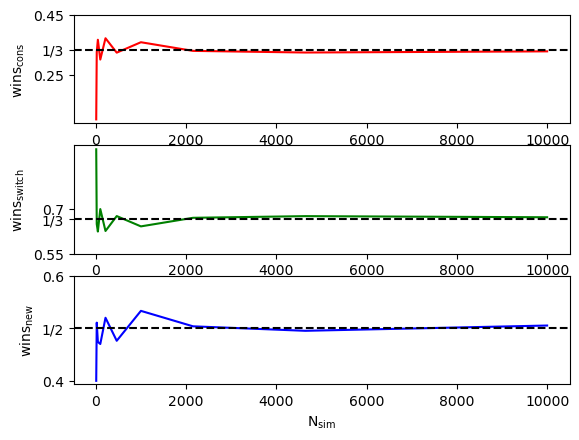

In [90]:
fig = plt.figure()

ax1 = fig.add_subplot(311)
ax1.plot(N_sim, conservative, "r")
ax1.set_ylabel("$\\rm wins_{cons}$")
ax1.axhline(1/3, color="black", ls="--")
ax1.set_yticks([1/3, 0.25, 0.45], ["1/3", "0.25", "0.45"])

ax2 = fig.add_subplot(312)
ax2.plot(N_sim, switcher, "g")
ax2.set_ylabel("$\\rm wins_{switch}$")
ax2.axhline(2/3, color="black", ls="--")
ax2.set_yticks([2/3, 0.55, 0.7], ["1/3", "0.55", "0.7"])

ax3 = fig.add_subplot(313)
ax3.plot(N_sim, last, "b")
ax3.set_xlabel("$\\rm N_{sim}$")
ax3.set_ylabel("$\\rm wins_{new}$")
ax3.axhline(1/2, color="black", ls="--")
ax3.set_yticks([1/2, 0.4, 0.6], ["1/2", "0.4", "0.6"])

## more doors!

In [79]:
N_doors = np.array(list(map(int, np.geomspace(10, 1e4, 10)))) #total doors
p_open = np.linspace(0.1, 0.7, 7) #fraction of total doors opened by the host

conservative = np.zeros((len(N_doors), len(p_open)))
switcher = np.zeros((len(N_doors), len(p_open)))
last = np.zeros((len(N_doors), len(p_open)))

n_sim = 6000 #where there is convergence

for d in N_doors:
    doors_n = np.zeros(d)
    doors_n[0] = 1 #the first one is always the car, since the probability of choosing whatever index is the same
    for p in p_open:
        c = s = l = 0
        for i in range(n_sim):
            choice_n = random.randint(0, d-1)
            if doors_n[choice_n]:
                c += 1
                #the conservative wins
                
            #remaining doors
            rem_picked = np.delete(doors_n, choice_n)
            #now the host opens some goat doors, so without considering the first door (with the car)
            open_doors = random.sample(range(1, d-2), int(p*d))
            rem_picked = np.delete(rem_picked, open_doors)
            #now the switcher chooses another door
            if rem_picked[random.randint(0, len(rem_picked)-1)]:
                s += 1

            #the doors for the last one include the one chosen by the conservative, but not the opened ones
            rem_unpicked = np.delete(doors_n, open_doors)
            if rem_unpicked[random.randint(0, len(rem_unpicked)-1)]:
                l += 1
        conservative[N_doors==d, p_open==p] = c/n_sim
        switcher[N_doors==d, p_open==p] = s/n_sim
        last[N_doors==d, p_open==p] = l/n_sim

Text(0.5, 1.0, 'newcomer')

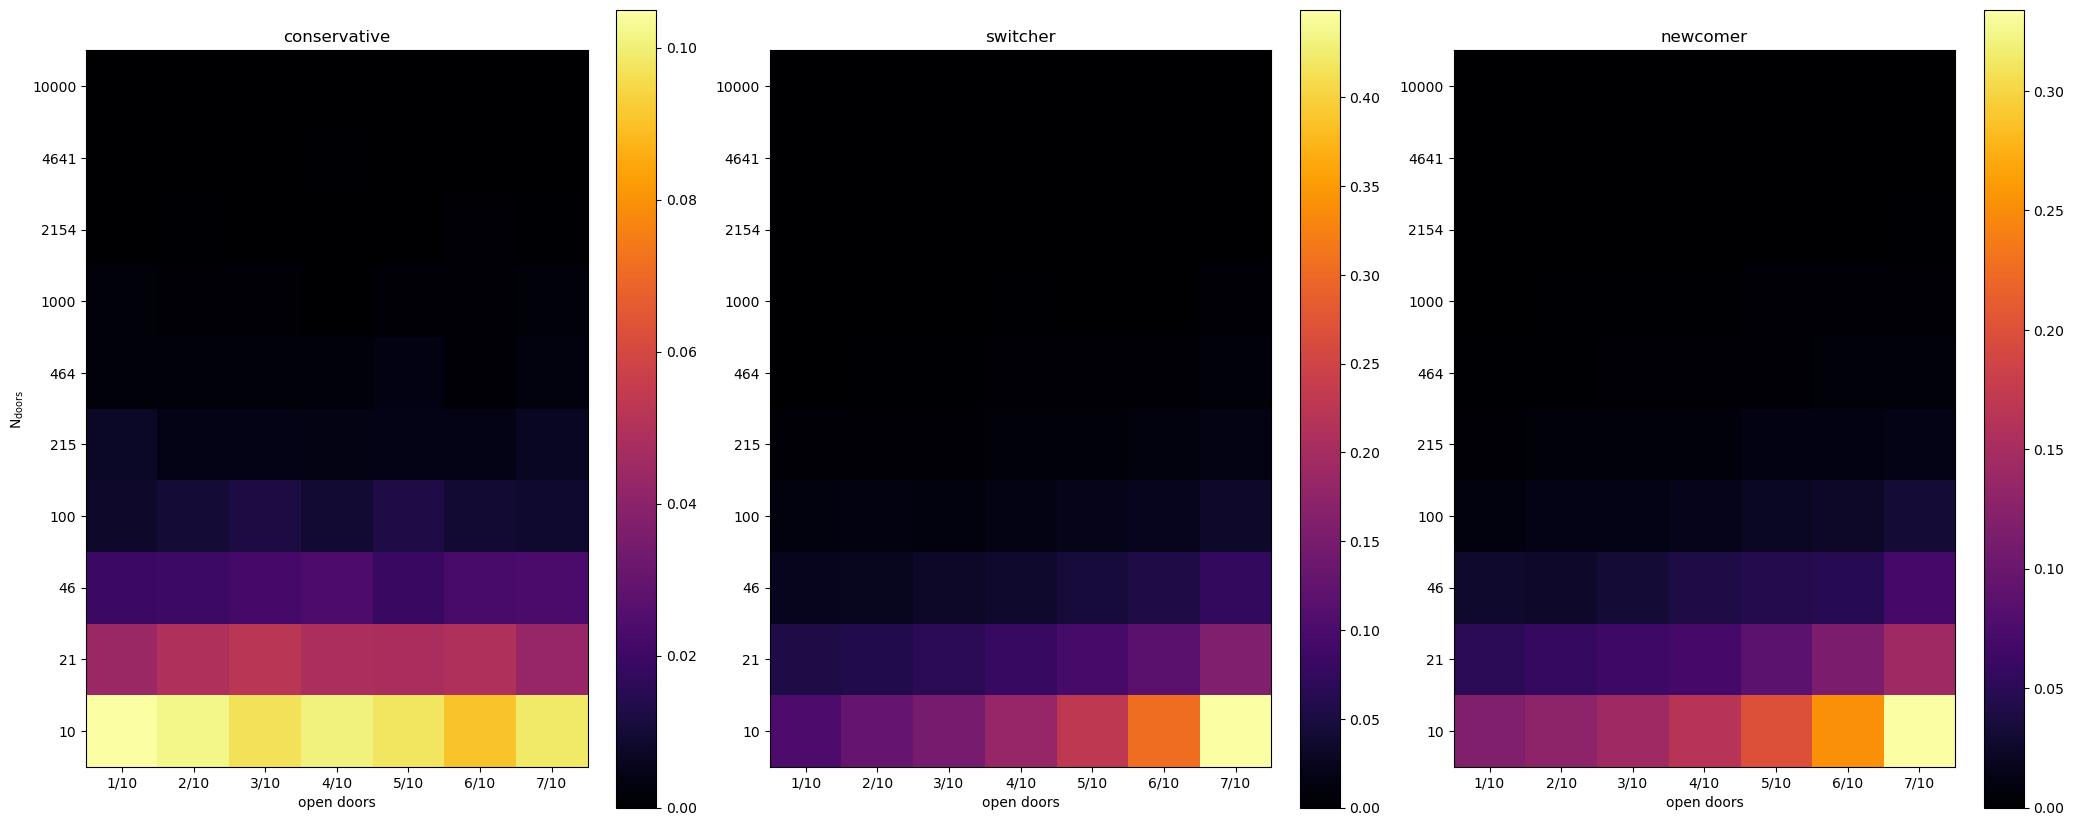

In [84]:
fig = plt.figure(figsize=(25, 60))
ax1 = fig.add_subplot(131)
im1 = ax1.imshow(conservative, origin="lower", cmap="inferno")
fig.colorbar(im1, ax=ax1, fraction=0.07)
ax1.set_xlabel("open doors")
ax1.set_ylabel("$\\rm N_{doors}$")
ax1.set_xticks(range(len(p_open)), labels=["1/10", "2/10", "3/10", "4/10", "5/10", "6/10", "7/10"])
ax1.set_yticks(range(len(N_doors)), labels=list(map(str, N_doors)))
ax1.set_title("conservative")

ax2 = fig.add_subplot(132)
im2 = ax2.imshow(switcher, origin="lower", cmap="inferno")
fig.colorbar(im2, ax=ax2, fraction=0.07)
ax2.set_xlabel("open doors")
ax2.set_xticks(range(len(p_open)), labels=["1/10", "2/10", "3/10", "4/10", "5/10", "6/10", "7/10"])
ax2.set_yticks(range(len(N_doors)), labels=list(map(str, N_doors)))
ax2.set_title("switcher")

ax3 = fig.add_subplot(133)
im3 = ax3.imshow(last, origin="lower", cmap="inferno")
fig.colorbar(im3, ax=ax3, fraction=0.07)
ax3.set_xlabel("open doors")
ax3.set_xticks(range(len(p_open)), labels=["1/10", "2/10", "3/10", "4/10", "5/10", "6/10", "7/10"])
ax3.set_yticks(range(len(N_doors)), labels=list(map(str, N_doors)))
ax3.set_title("newcomer")

Text(0.5, 1.0, 'theoretical switcher')

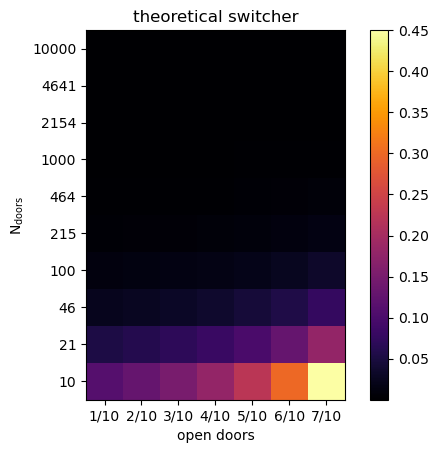

In [83]:
#the theoretical probability for the switcher:
pp, NN = np.meshgrid(p_open, N_doors)

def p_switch(p_frac, N):
    p = N*p_frac
    return (1-1/N)/(N-p-1)

fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(p_switch(pp, NN), cmap="inferno", origin="lower")
fig.colorbar(im, ax=ax)
ax.set_xlabel("open doors")
ax.set_ylabel("$\\rm N_{doors}$")
ax.set_xticks(range(len(p_open)), labels=["1/10", "2/10", "3/10", "4/10", "5/10", "6/10", "7/10"])
ax.set_yticks(range(len(N_doors)), labels=list(map(str, N_doors)))
ax.set_title("theoretical switcher")

Text(0.5, 1.0, 'difference theoretical-simulation')

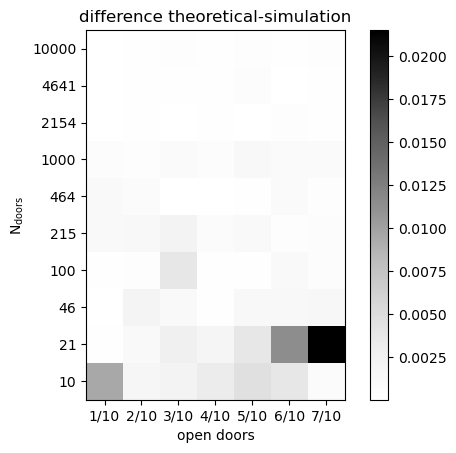

In [82]:
fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(abs(p_switch(pp, NN)-switcher), cmap="Greys", origin="lower")
fig.colorbar(im, ax=ax)
ax.set_xlabel("open doors")
ax.set_ylabel("$\\rm N_{doors}$")
ax.set_xticks(range(len(p_open)), labels=["1/10", "2/10", "3/10", "4/10", "5/10", "6/10", "7/10"])
ax.set_yticks(range(len(N_doors)), labels=list(map(str, N_doors)))
ax.set_title("difference theoretical-simulation")

# Log PDF

In [177]:
n = 1000
x = np.random.uniform(0.1, 10, n)

Text(0.5, 0, 'x')

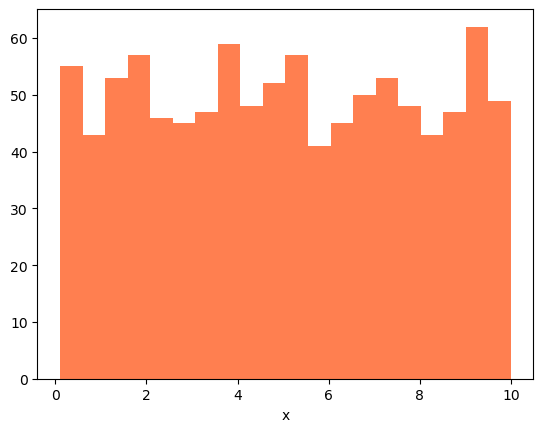

In [179]:
plt.hist(x, int(n/50), color="coral")
plt.xlabel("x")

Text(0.5, 0, 'y')

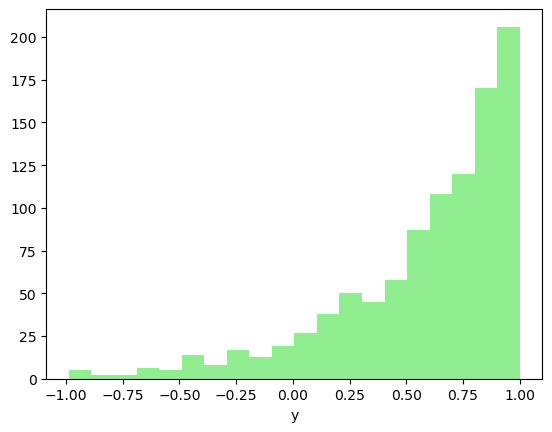

In [180]:
y = np.log10(x)

plt.hist(y, int(n/50), color="lightgreen")
plt.xlabel("y")

Text(0.5, 0, 'y')

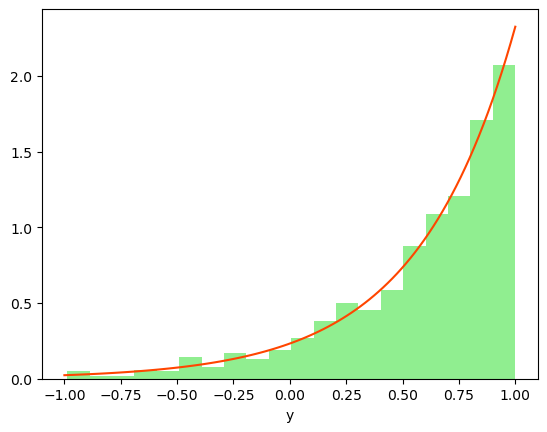

In [181]:
#p(y)=(dx/dy)p(x)
#p(x)=1/(10-0.1)
#x=10^y
#dx/dy=ln(10)10^y
points = np.linspace(-1, 1, 100)
plt.hist(y, int(n/50), color="lightgreen", density=True)
pdf = (10**points)*np.log(10)
pdf_n = pdf/(10-0.1)
plt.plot(points, pdf_n, color="orangered")
plt.xlabel("y")

In [184]:
print("log(mean(x)) = ", np.log10(np.mean(x)))
print("mean(log(x)) = ", np.mean(y))
print("\n...they change")

log(mean(x)) =  0.7026839462819124
mean(log(x)) =  0.5837716094107186

...they change


In [185]:
print("log(median(x)) = ", np.log10(np.median(x)))
print("median(log(x)) = ", np.median(y))
print("\n...they are the same!")

log(median(x)) =  0.6970885984275037
median(log(x)) =  0.6970885442430019

...they are the same!
